# PART 13

Haikal Ali_1103223071_TK46GAB

# Chapter 13 — Eigendecomposition


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

np.set_printoptions(precision=4, suppress=True)

## 1. Eigendecomposition hanya untuk matriks persegi

Eigendecomposition hanya didefinisikan untuk matriks persegi. Matriks berukuran $M \times M$ memiliki $M$ eigenvalue dan $M$ eigenvector yang berpasangan.

Persamaan dasarnya adalah:

$$
Av = \lambda v
$$

Artinya, efek perkalian matriks $A$ terhadap vector $v$ sama seperti efek perkalian scalar $\lambda$ terhadap vector yang sama. Matrix tidak sama dengan scalar; yang sama adalah efeknya terhadap vector tersebut.

## 2. Interpretasi eigenvalue dan eigenvector

Secara geometri, eigenvector adalah arah khusus yang tidak berubah arah setelah dikalikan matriks. Arah tersebut hanya diregangkan atau dibalik oleh eigenvalue.

Dalam statistik, eigendecomposition digunakan pada PCA. Eigenvalue dari covariance matrix menunjukkan seberapa besar variance yang dijelaskan oleh suatu arah/component.

Dalam noise reduction dan dimension reduction, eigenvalue kecil sering dianggap sebagai arah yang kontribusinya kecil terhadap data, sehingga dapat dikurangi atau dibuang.

## 3. Mencari eigenvalue

Untuk mencari eigenvalue, mulai dari:

$$
Av = \lambda v
$$

Susun ulang:

$$
Av - \lambda v = 0
$$

Karena $A - \lambda$ bukan operasi linear algebra yang valid, scalar $\lambda$ dipakai untuk menggeser matriks dengan identity matrix:

$$
(A - \lambda I)v = 0
$$

Agar punya solusi nontrivial, matriks $(A - \lambda I)$ harus singular, sehingga determinant-nya nol:

$$
\det(A - \lambda I) = 0
$$

Persamaan ini disebut **characteristic polynomial**.

In [2]:
# Contoh mencari eigenvalue dengan NumPy
matrix = np.array([
  [1, 2],
  [3, 4]
])

# np.linalg.eig mengembalikan eigenvalue dan eigenvector
evals = np.linalg.eig(matrix)[0]
print(evals)

[-0.3723  5.3723]


## 4. Mencari eigenvector

Eigenvector ditemukan sebagai basis null space dari matriks yang sudah digeser oleh eigenvalue:

$$
v_i \in N(A - \lambda_i I)
$$

Di NumPy, eigenvector disimpan pada **kolom**, bukan baris. Eigenvector pada kolom pertama berpasangan dengan eigenvalue pertama.

In [3]:
evals, evecs = np.linalg.eig(matrix)

print('Eigenvalues:')
print(evals)

print('\nEigenvectors dalam kolom:')
print(evecs)

# Cek persamaan Av = lambda v untuk eigenpair pertama
v = evecs[:, 0]
lam = evals[0]

print('\nA @ v:')
print(matrix @ v)

print('\nlambda * v:')
print(lam * v)

Eigenvalues:
[-0.3723  5.3723]

Eigenvectors dalam kolom:
[[-0.8246 -0.416 ]
 [ 0.5658 -0.9094]]

A @ v:
[ 0.307  -0.2106]

lambda * v:
[ 0.307  -0.2106]


## 5. Sign dan scale eigenvector tidak unik

Eigenvector penting karena arahnya, bukan panjangnya. Jika $v$ adalah eigenvector, maka $\alpha v$ juga eigenvector untuk scalar real $\alpha \neq 0$.

Tanda eigenvector juga tidak unik. Vector $v$ dan $-v$ tetap mewakili arah eigenvector yang sama.

## 6. Diagonalizing a square matrix

Untuk matriks $M \times M$, semua persamaan eigenvalue dapat ditulis ringkas sebagai:

$$
AV = V\Lambda
$$

$V$ berisi eigenvector pada kolom, sedangkan $\Lambda$ adalah matriks diagonal berisi eigenvalue.

Bentuk lain yang ekuivalen:

$$
A = V\Lambda V^{-1}
$$

$$
\Lambda = V^{-1}AV
$$

In [4]:
evals, evecs = np.linalg.eig(matrix)
D = np.diag(evals)

A_recon = evecs @ D @ np.linalg.inv(evecs)

print('Matrix asli:')
print(matrix)

print('\nMatrix hasil rekonstruksi V @ D @ inv(V):')
print(A_recon)

print('\nFrobenius distance:')
print(np.linalg.norm(matrix - A_recon, 'fro'))

Matrix asli:
[[1 2]
 [3 4]]

Matrix hasil rekonstruksi V @ D @ inv(V):
[[1. 2.]
 [3. 4.]]

Frobenius distance:
9.485749680535094e-16


## 7. Sifat khusus matriks simetris

Matriks simetris memiliki eigenvector yang saling orthogonal. Jika semua eigenvector dibuat unit norm, maka matriks eigenvector menjadi orthogonal:

$$
V^TV = I
$$

Matriks simetris juga memiliki eigenvalue real-valued. Karena itu, untuk matriks simetris lebih tepat memakai `np.linalg.eigh()` dibanding `np.linalg.eig()`.

In [5]:
# Membuat matriks simetris dari random matrix
A = np.random.randint(-3, 4, (3, 3))
A = A.T @ A

L, V = np.linalg.eigh(A)

print('Matrix A simetris:')
print(A)

print('\nEigenvalues:')
print(L)

print('\nV.T @ V:')
print(V.T @ V)

Matrix A simetris:
[[22 -1  3]
 [-1  9  5]
 [ 3  5  5]]

Eigenvalues:
[ 1.1684 12.3161 22.5155]

V.T @ V:
[[ 1. -0. -0.]
 [-0.  1. -0.]
 [-0. -0.  1.]]


## 8. Eigendecomposition pada singular matrix

Singular matrix tetap bisa dieigendecompose. Sifat khususnya adalah minimal ada satu eigenvalue bernilai nol.

In [6]:
A = np.array([
  [1, 4, 7],
  [2, 5, 8],
  [3, 6, 9]
])

L, V = np.linalg.eig(A)

print(f'Rank = {np.linalg.matrix_rank(A)}')
print('\nEigenvalues:')
print(np.round(L, 4))
print('\nEigenvectors:')
print(np.round(V, 4))

Rank = 2

Eigenvalues:
[16.1168 -1.1168 -0.    ]

Eigenvectors:
[[-0.4645 -0.8829  0.4082]
 [-0.5708 -0.2395 -0.8165]
 [-0.677   0.4039  0.4082]]


## 9. Quadratic form dan definiteness

Quadratic form ditulis sebagai:

$$
w^TAw = \alpha
$$

Definiteness ditentukan dari tanda eigenvalue:

| Category | Quadratic form | Eigenvalues | Invertible |
|---|---|---|---|
| Positive definite | Positive | semua positif | Ya |
| Positive semidefinite | Nonnegative | positif dan nol | Tidak |
| Indefinite | positif dan negatif | positif dan negatif | Bergantung |
| Negative semidefinite | Nonpositive | negatif dan nol | Tidak |
| Negative definite | Negative | semua negatif | Ya |

Setiap matriks berbentuk $A^TA$ bersifat positive definite atau positive semidefinite.

In [7]:
A = np.random.randn(5, 3)
S = A.T @ A
L = np.linalg.eigvalsh(S)

print('Eigenvalues dari A.T @ A:')
print(L)

print('\nSemua eigenvalue nonnegative?')
print(np.all(L >= -1e-10))

Eigenvalues dari A.T @ A:
[ 2.0643  5.7092 10.2593]

Semua eigenvalue nonnegative?
True


## 10. Generalized eigendecomposition

Generalized eigendecomposition mengganti identity matrix pada persamaan eigenvalue dengan matriks lain:

$$
Av = \lambda Bv
$$

Secara konsep, ini mirip eigendecomposition dari $AB^{-1}$, tetapi implementasinya tidak harus benar-benar menghitung inverse $B$.

Di SciPy, generalized eigendecomposition dapat dihitung dengan `scipy.linalg.eigh(A, B)` jika matriksnya simetris.

In [8]:
# Membuat dua matriks simetris positive definite
A = np.random.randn(4, 4)
A = A @ A.T

B = np.random.randn(4, 4)
B = B @ B.T + A / 10

# Generalized eigendecomposition
gevals, gevecs = la.eigh(A, B)

print('Generalized eigenvalues:')
print(gevals)

print('\nCek V.T @ B @ V:')
print(gevecs.T @ B @ gevecs)

Generalized eigenvalues:
[0.0012 0.3228 1.2681 3.2043]

Cek V.T @ B @ V:
[[ 1.  0.  0. -0.]
 [-0.  1. -0. -0.]
 [ 0. -0.  1.  0.]
 [-0. -0.  0.  1.]]


# Code Exercises

## Exercise 13-1

Eigenvector dari $A^{-1}$ sama dengan eigenvector dari $A$, sedangkan eigenvalue-nya menjadi $\lambda^{-1}$.

Bukti singkat:

$$
Av = \lambda v
$$

Kalikan dengan $A^{-1}$:

$$
v = \lambda A^{-1}v
$$

$$
A^{-1}v = \frac{1}{\lambda}v
$$

Jadi eigenvalue dari $A^{-1}$ adalah kebalikan eigenvalue dari $A$.

In [9]:
np.random.seed(13)

R = np.random.randn(5, 5)
A = R.T @ R + 0.1 * np.eye(5)  # simetris dan full-rank
Ainv = np.linalg.inv(A)

L, V = np.linalg.eigh(A)
Linv, Vinv = np.linalg.eigh(Ainv)

print('Eigenvalues A:')
print(L)

print('\nEigenvalues A^-1:')
print(Linv)

print('\nSorted reciprocal eigenvalues A:')
print(np.sort(1 / L))

# Cocokkan eigenvector berdasarkan eigenvalue reciprocal terdekat
print('\nKemiripan arah eigenvector |dot product|:')
for i, lam_inv in enumerate(Linv):
  j = np.argmin(np.abs((1 / L) - lam_inv))
  similarity = np.abs(np.dot(V[:, j], Vinv[:, i]))
  print(f'eigenvector A^-1 ke-{i}: cocok dengan A ke-{j}, similarity = {similarity:.6f}')

Eigenvalues A:
[0.3259 2.7894 4.0496 5.8447 9.7407]

Eigenvalues A^-1:
[0.1027 0.1711 0.2469 0.3585 3.0688]

Sorted reciprocal eigenvalues A:
[0.1027 0.1711 0.2469 0.3585 3.0688]

Kemiripan arah eigenvector |dot product|:
eigenvector A^-1 ke-0: cocok dengan A ke-4, similarity = 1.000000
eigenvector A^-1 ke-1: cocok dengan A ke-3, similarity = 1.000000
eigenvector A^-1 ke-2: cocok dengan A ke-2, similarity = 1.000000
eigenvector A^-1 ke-3: cocok dengan A ke-1, similarity = 1.000000
eigenvector A^-1 ke-4: cocok dengan A ke-0, similarity = 1.000000


## Exercise 13-2

Re-create panel kiri Figure 13-1, tetapi memakai baris dari $V$ sebagai eigenvector. Ini sengaja salah secara coding, dan hasilnya menunjukkan bahwa baris $V$ tidak memenuhi tes geometri eigenvector.

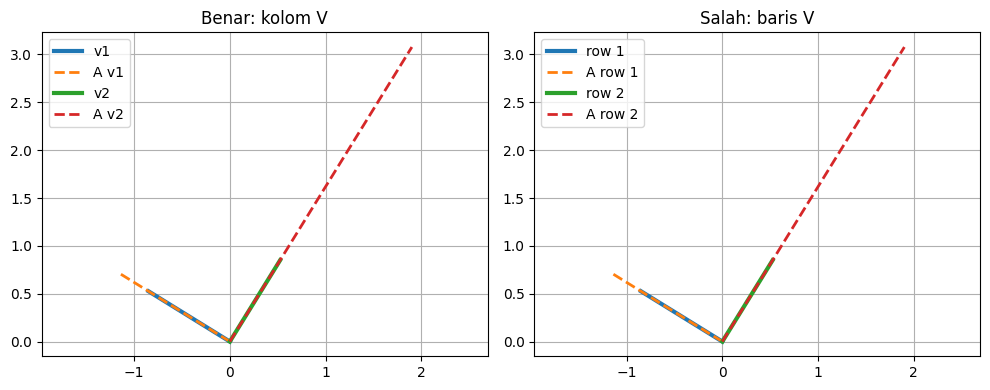

In [10]:
A = np.array([
  [2, 1],
  [1, 3]
])

L, V = np.linalg.eigh(A)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Benar: eigenvector ada di kolom V
for i in range(2):
  v = V[:, i]
  Av = A @ v
  axes[0].plot([0, v[0]], [0, v[1]], linewidth=3, label=f'v{i+1}')
  axes[0].plot([0, Av[0]], [0, Av[1]], '--', linewidth=2, label=f'A v{i+1}')

axes[0].set_title('Benar: kolom V')
axes[0].axis('equal')
axes[0].grid(True)
axes[0].legend()

# Salah: memakai baris V
for i in range(2):
  v = V[i, :]
  Av = A @ v
  axes[1].plot([0, v[0]], [0, v[1]], linewidth=3, label=f'row {i+1}')
  axes[1].plot([0, Av[0]], [0, Av[1]], '--', linewidth=2, label=f'A row {i+1}')

axes[1].set_title('Salah: baris V')
axes[1].axis('equal')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Exercise 13-3

Eigenvalue dan eigenvector harus tetap berpasangan. Jika eigenvalue ditukar tanpa menukar eigenvector-nya, rekonstruksi matriks menjadi salah.

Frobenius distances:
None: 0.000000
All: 89.336777
Largest two: 16.118112
Smallest two: 13.625542


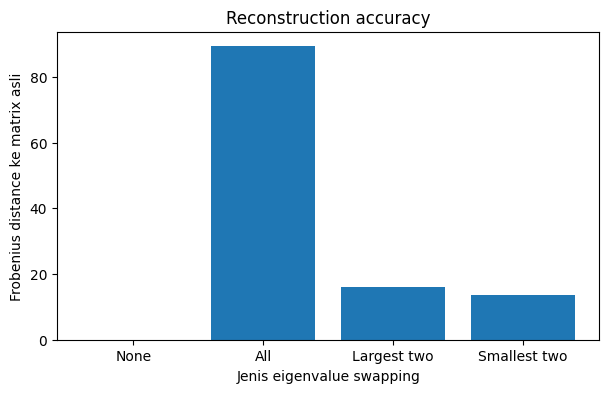

In [11]:
np.random.seed(13)

A = np.random.randint(-10, 11, (5, 5))
A = A + A.T  # metode additive untuk membuat matriks simetris

L, V = np.linalg.eigh(A)
D = np.diag(L)

A_recon = V @ D @ np.linalg.inv(V)
dist_none = np.linalg.norm(A - A_recon, 'fro')

# Tukar semua eigenvalue secara random
perm = np.random.permutation(len(L))
D_all = np.diag(L[perm])
dist_all = np.linalg.norm(A - V @ D_all @ np.linalg.inv(V), 'fro')

# Tukar dua eigenvalue terbesar
idx_largest = np.argsort(L)[-2:]
L_largest = L.copy()
L_largest[idx_largest] = L_largest[idx_largest[::-1]]
dist_largest = np.linalg.norm(A - V @ np.diag(L_largest) @ np.linalg.inv(V), 'fro')

# Tukar dua eigenvalue terkecil
idx_smallest = np.argsort(L)[:2]
L_smallest = L.copy()
L_smallest[idx_smallest] = L_smallest[idx_smallest[::-1]]
dist_smallest = np.linalg.norm(A - V @ np.diag(L_smallest) @ np.linalg.inv(V), 'fro')

distances = [dist_none, dist_all, dist_largest, dist_smallest]
labels = ['None', 'All', 'Largest two', 'Smallest two']

print('Frobenius distances:')
for label, dist in zip(labels, distances):
  print(f'{label}: {dist:.6f}')

plt.figure(figsize=(7, 4))
plt.bar(labels, distances)
plt.ylabel('Frobenius distance ke matrix asli')
plt.xlabel('Jenis eigenvalue swapping')
plt.title('Reconstruction accuracy')
plt.show()

## Exercise 13-4

Eigenvalue complex dari random matrix tersebar dalam lingkaran dengan radius yang proporsional terhadap ukuran matriks. Di sini dibuat 123 random matrix berukuran $42 \times 42$, lalu eigenvalue dibagi $\sqrt{42}$ dan diplot pada complex plane.

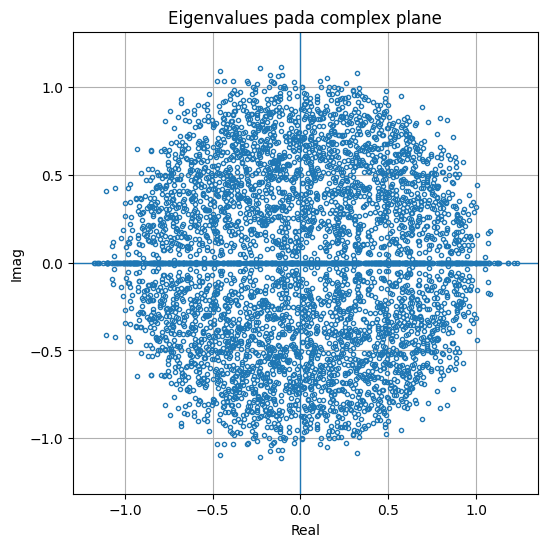

In [12]:
np.random.seed(13)

n_mats = 123
mat_size = 42
all_evals = []

for _ in range(n_mats):
  A = np.random.randn(mat_size, mat_size)
  L = np.linalg.eigvals(A) / np.sqrt(mat_size)
  all_evals.extend(L)

all_evals = np.array(all_evals)

plt.figure(figsize=(6, 6))
plt.plot(np.real(all_evals), np.imag(all_evals), 'o', markersize=3, markerfacecolor='none')
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Eigenvalues pada complex plane')
plt.axis('equal')
plt.grid(True)
plt.show()

## Exercise 13-5

Eigenvector adalah basis null space dari matrix yang sudah digeser oleh eigenvalue. Exercise ini juga menunjukkan risiko precision error: secara teori shifted matrix harus singular, tetapi pada komputer bisa tampak full-rank karena rounding error.

In [13]:
np.random.seed(13)

A = np.random.randn(3, 3)
A = A + A.T  # simetris

L, V = np.linalg.eigh(A)

print('Eigenvalues:')
print(L)

for i, lam in enumerate(L):
  shifted = A - lam * np.eye(A.shape[0])
  ns = la.null_space(shifted)
  rank_shifted = np.linalg.matrix_rank(shifted)

  print(f'\nEigenvalue ke-{i}: {lam:.6f}')
  print(f'Rank shifted matrix: {rank_shifted}')
  print(f'Ukuran null space: {ns.shape}')

  if ns.shape[1] > 0:
    null_vec = ns[:, 0]
    eig_vec = V[:, i]
    similarity = np.abs(np.dot(null_vec, eig_vec))
    print(f'|dot(null vector, eigenvector)| = {similarity:.6f}')
  else:
    print('Null space kosong karena precision error numerik.')

Eigenvalues:
[-1.9374  1.4239  4.7363]

Eigenvalue ke-0: -1.937414
Rank shifted matrix: 2
Ukuran null space: (3, 1)
|dot(null vector, eigenvector)| = 1.000000

Eigenvalue ke-1: 1.423900
Rank shifted matrix: 2
Ukuran null space: (3, 1)
|dot(null vector, eigenvector)| = 1.000000

Eigenvalue ke-2: 4.736307
Rank shifted matrix: 2
Ukuran null space: (3, 1)
|dot(null vector, eigenvector)| = 1.000000


## Exercise 13-6

Membuat matriks simetris dari eigenvalue dan eigenvector yang ditentukan sendiri. Gunakan diagonal matrix positif sebagai eigenvalue dan matrix $Q$ dari QR decomposition sebagai eigenvector.

In [14]:
np.random.seed(13)

D = np.diag([1, 2, 3, 4])
Q, R = np.linalg.qr(np.random.randn(4, 4))

A = Q @ D @ Q.T

print('Apakah A simetris?')
print(np.allclose(A, A.T))

print('\nEigenvalues yang ditentukan:')
print(np.diag(D))

print('\nEigenvalues hasil eigendecomposition A:')
print(np.linalg.eigvalsh(A))

Apakah A simetris?
True

Eigenvalues yang ditentukan:
[1 2 3 4]

Eigenvalues hasil eigendecomposition A:
[1. 2. 3. 4.]


## Exercise 13-7

Exercise ini mengulang regularization dari Exercise 12-4, tetapi mengganti squared Frobenius norm dengan rata-rata eigenvalue. Ini disebut **shrinkage regularization**.

Cell berikut memakai variabel dari Exercise 12-4:

- `X_original`: design matrix tanpa multicollinearity
- `X_multicol`: design matrix dengan multicollinearity
- `y`: observed data

Jika variabel tersebut belum ada, jalankan dulu notebook Chapter 12 bagian Exercise 12-3 dan 12-4.

In [15]:
def regularized_fit_with_eigenmean(X, y, gamma):
  XtX = X.T @ X
  eig_mean = np.mean(np.linalg.eigvalsh(XtX))
  reg = gamma * eig_mean * np.eye(XtX.shape[0])
  beta = np.linalg.inv(XtX + reg) @ X.T @ y
  y_hat = X @ beta
  r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - np.mean(y))**2)
  return r2, beta

required_vars = ['X_original', 'X_multicol', 'y']
missing = [var for var in required_vars if var not in globals()]

if missing:
  print('Variabel berikut belum tersedia:', missing)
  print('Jalankan dulu bagian Exercise 12-3 dan 12-4 dari Chapter 12.')
else:
  gammas = np.linspace(0, 0.2, 40)
  r2_original = []
  r2_multicol = []

  for gamma in gammas:
    r2_o, _ = regularized_fit_with_eigenmean(X_original, y, gamma)
    r2_m, _ = regularized_fit_with_eigenmean(X_multicol, y, gamma)
    r2_original.append(r2_o)
    r2_multicol.append(r2_m)

  plt.figure(figsize=(7, 4))
  plt.plot(gammas, r2_original, 's-', label='Original')
  plt.plot(gammas, r2_multicol, 'o-', label='Multicol.')
  plt.xlabel('Regularization gamma')
  plt.ylabel('$R^2$ fit to data')
  plt.legend()
  plt.grid(True)
  plt.show()

Variabel berikut belum tersedia: ['X_original', 'X_multicol', 'y']
Jalankan dulu bagian Exercise 12-3 dan 12-4 dari Chapter 12.


## Exercise 13-8

Membuat surrogate data dengan correlation matrix yang ditentukan:

$$
Y = V\Lambda^{1/2}X
$$

$V$ dan $\Lambda$ berasal dari eigendecomposition correlation matrix, sedangkan $X$ adalah data random tidak berkorelasi.

In [16]:
np.random.seed(13)

R = np.array([
  [1, 0.2, 0.9],
  [0.2, 1, 0.3],
  [0.9, 0.3, 1]
])

N = 3
T = 10000
X = np.random.randn(N, T)

L, V = np.linalg.eigh(R)
Y = V @ np.diag(np.sqrt(L)) @ X

emp_corr = np.corrcoef(Y)

print('Target correlation matrix R:')
print(R)

print('\nEmpirical correlation matrix dari Y:')
print(emp_corr)

print('\nMaksimum absolute difference:')
print(np.max(np.abs(R - emp_corr)))

Target correlation matrix R:
[[1.  0.2 0.9]
 [0.2 1.  0.3]
 [0.9 0.3 1. ]]

Empirical correlation matrix dari Y:
[[1.     0.2012 0.8981]
 [0.2012 1.     0.2997]
 [0.8981 0.2997 1.    ]]

Maksimum absolute difference:
0.0019213608141256389


## Exercise 13-9

Whitening digunakan untuk menghilangkan correlation dari multivariate time series. Dengan data dari Exercise 13-8, whitening dilakukan dengan eigenvector dan inverse square root eigenvalue dari correlation matrix.

In [17]:
# Whitening untuk data berorientasi channels x time
Y_white = np.diag(1 / np.sqrt(L)) @ V.T @ Y

white_corr = np.corrcoef(Y_white)

print('Correlation matrix setelah whitening:')
print(white_corr)

print('\nJarak ke identity matrix:')
print(np.linalg.norm(white_corr - np.eye(N), 'fro'))

Correlation matrix setelah whitening:
[[ 1.      0.0076 -0.0084]
 [ 0.0076  1.      0.0073]
 [-0.0084  0.0073  1.    ]]

Jarak ke identity matrix:
0.019064671911952994


## Exercise 13-10

Pada generalized eigendecomposition, eigenvector tidak orthogonal biasa walaupun kedua matriks simetris. Jadi $V^{-1} \neq V^T$. Namun eigenvector orthogonal terhadap $B$, sehingga:

$$
V^TBV = I
$$

Apakah inv(V) sama dengan V.T?
False

V.T @ B @ V:
[[ 1.  0.  0. -0.  0.]
 [ 0.  1.  0.  0.  0.]
 [-0.  0.  1.  0. -0.]
 [-0.  0.  0.  1.  0.]
 [ 0.  0. -0.  0.  1.]]


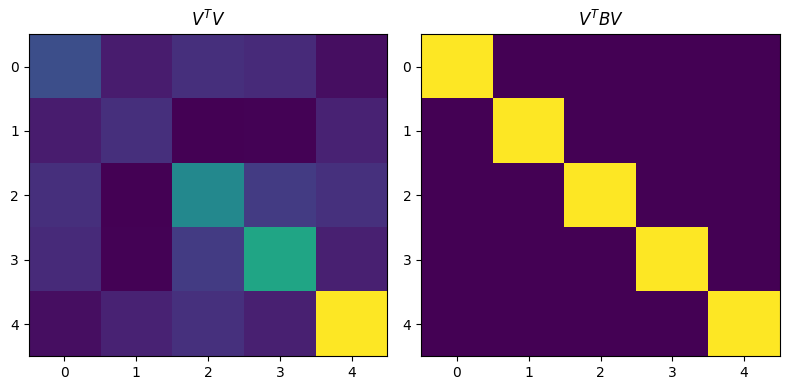

In [18]:
np.random.seed(13)

A = np.random.randn(5, 5)
A = A @ A.T

B = np.random.randn(5, 5)
B = B @ B.T + np.eye(5)

L, V = la.eigh(A, B)

Vinv = np.linalg.inv(V)
Vt = V.T
VtBV = V.T @ B @ V

print('Apakah inv(V) sama dengan V.T?')
print(np.allclose(Vinv, Vt))

print('\nV.T @ B @ V:')
print(VtBV)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(V.T @ V, aspect='auto')
axes[0].set_title('$V^T V$')

axes[1].imshow(VtBV, aspect='auto')
axes[1].set_title('$V^T B V$')

plt.tight_layout()
plt.show()

## Exercise 13-11

Exercise ini mengecek scaling eigenvector. Untuk matriks umum, scaling eigenvector tidak mengubah rekonstruksi jika memakai $V^{-1}$, karena scaling akan dibatalkan oleh inverse.

Untuk matriks simetris, $V^T$ bisa menggantikan $V^{-1}$ hanya jika $V$ orthonormal. Jika eigenvector diskalakan, $V^T$ tidak lagi sama dengan inverse.

In [19]:
np.random.seed(13)

# Matrix random integer
A = np.random.randint(-14, 15, (4, 4))

L, V = np.linalg.eig(A)
D = np.diag(L)

A_recon = V @ D @ np.linalg.inv(V)
err_original = np.linalg.norm(A - A_recon, 'fro')

# Norm eigenvector untuk bilangan kompleks: sqrt(sum(conj(v)*v))
evec_norms = []
for i in range(V.shape[1]):
  v = V[:, i]
  evec_norms.append(np.sqrt(np.sum(np.conj(v) * v)).real)

print('Error rekonstruksi matrix umum:')
print(err_original)

print('\nNorm setiap eigenvector:')
print(evec_norms)

# Scaling eigenvectors
scalar = np.pi
Vp = scalar * V
A_recon_scaled = Vp @ D @ np.linalg.inv(Vp)
err_scaled = np.linalg.norm(A - A_recon_scaled, 'fro')

scaled_norms = []
for i in range(Vp.shape[1]):
  v = Vp[:, i]
  scaled_norms.append(np.sqrt(np.sum(np.conj(v) * v)).real)

print('\nError setelah eigenvector dikali pi, tetap pakai inverse:')
print(err_scaled)

print('\nNorm eigenvector setelah dikali pi:')
print(scaled_norms)

# Kasus simetris
S = np.random.randint(-14, 15, (4, 4))
S = S + S.T

Ls, Vs = np.linalg.eigh(S)
Ds = np.diag(Ls)

S_recon = Vs @ Ds @ Vs.T
err_sym = np.linalg.norm(S - S_recon, 'fro')

Vsp = np.pi * Vs
S_recon_scaled_transpose = Vsp @ Ds @ Vsp.T
err_sym_scaled_transpose = np.linalg.norm(S - S_recon_scaled_transpose, 'fro')

S_recon_scaled_inverse = Vsp @ Ds @ np.linalg.inv(Vsp)
err_sym_scaled_inverse = np.linalg.norm(S - S_recon_scaled_inverse, 'fro')

print('\nError simetris dengan V.T:')
print(err_sym)

print('\nError simetris setelah V dikali pi lalu tetap pakai V.T:')
print(err_sym_scaled_transpose)

print('\nError simetris setelah V dikali pi lalu pakai inverse:')
print(err_sym_scaled_inverse)

Error rekonstruksi matrix umum:
2.5523725340761806e-14

Norm setiap eigenvector:
[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9999999999999999)]

Error setelah eigenvector dikali pi, tetap pakai inverse:
2.4236707674539624e-14

Norm eigenvector setelah dikali pi:
[np.float64(3.1415926535897936), np.float64(3.1415926535897936), np.float64(3.141592653589793), np.float64(3.141592653589793)]

Error simetris dengan V.T:
2.377147982610191e-14

Error simetris setelah V dikali pi lalu tetap pakai V.T:
345.34553922621444

Error simetris setelah V dikali pi lalu pakai inverse:
1.3794046379856668e-14
